In [1]:
import sys
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from dotenv import load_dotenv

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

load_dotenv(os.path.join(PROJECT_ROOT, '.env'))
from apps.db.database import engine

query = """
    SELECT source, published_at, content, sentiment_score, sentiment_reason 
    FROM news_sentiment 
    ORDER BY published_at ASC
"""
df_news = pd.read_sql(query, con=engine)
df_news.set_index('published_at', inplace=True)

print(f"Total number of articles analyzed: {len(df_news)}")
display(df_news.head())

Total number of articles analyzed: 130


,source,content,sentiment_score,sentiment_reason
published_at,,,,
2026-07-29 22:38:29+00:00,Crypto Briefing,Strategy tokenizes its stock on Solana for rou...,0.15,Tokenization introduces new market mechanisms ...
2026-07-29 22:47:48+00:00,Biztoc.com,Prediction: Bitcoin Will Be Worth $2.5 Trillio...,0.15,The article presents highly speculative long-t...
2026-07-30 00:19:25+00:00,C-sharpcorner.com,Mastering Angular Performance: Demystifying Ng...,0.15,"The topic is unrelated to cryptocurrency, resu..."
2026-07-30 00:48:51+00:00,Biztoc.com,Vanguard fund adds millions to Peter Thiel-bac...,0.45,Increased institutional investment in a Bitcoi...
2026-07-30 01:03:14+00:00,Crypto Briefing,Banco Bradesco approves $2B capital increase t...,0.45,Bank approval signals institutional interest i...


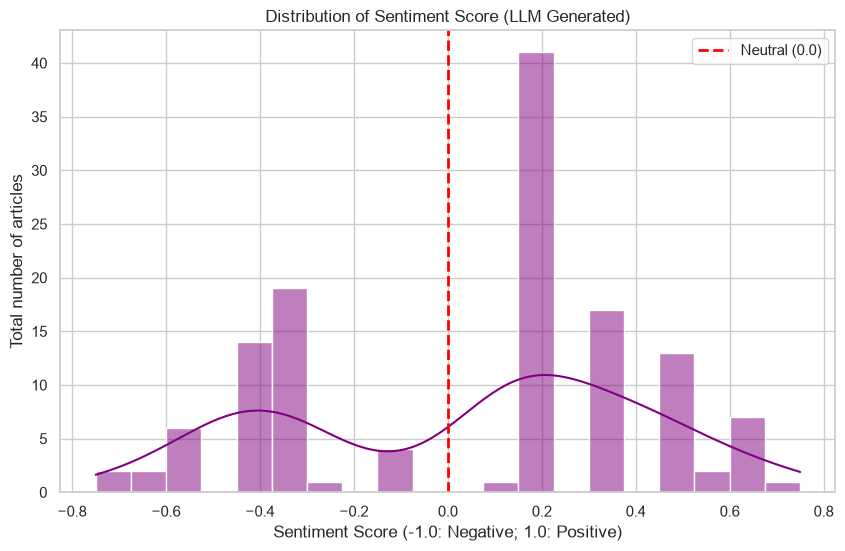

In [4]:
plt.figure(figsize=(10, 6))
sns.set_theme(style='whitegrid')

sns.histplot(df_news['sentiment_score'], bins=20, kde=True, color='purple')
plt.title('Distribution of Sentiment Score (LLM Generated)')
plt.xlabel('Sentiment Score (-1.0: Negative; 1.0: Positive)')
plt.ylabel('Total number of articles')
plt.axvline(0, color='red', linestyle='dashed', linewidth=2, label="Neutral (0.0)")
plt.legend()
plt.show()

In [5]:
daily_sentiment = df_news['sentiment_score'].resample('D').mean().reset_index()

fig = px.line(
    daily_sentiment,
    x='published_at',
    y='sentiment_score',
    markers=True,
    title='Daily Fluctuations in Average Sentiment Score'
)

fig.add_hline(y=0.0, line_dash='dash', line_color='red', annotation_text='Neural')

fig.update_layout(
    xaxis_title='Day',
    yaxis_title='Average of Sentiment Score',
    yaxis=dict(range=[-1.1, 1.1]),
    hovermode='x'
)

fig.show()

In [8]:
top_positive = df_news.nlargest(5, 'sentiment_score')
top_negative = df_news.nsmallest(5, 'sentiment_score')

print("=== TOP 5 POSITIVE NEWS ===")
for i, row in top_positive.iterrows():
    print(f"[{row['sentiment_score']}] | Source: {row['source']}")
    print(f"Reason (LLM): {row['sentiment_reason']}")
    print(f"Content: {row['content'][:150]}...\n")
    
print("-"*50)

print("=== TOP 5 NEGATIVE NEWS ===")
for i, row in top_negative.iterrows():
    print(f"[{row['sentiment_score']}] | Source: {row['source']}")
    print(f"Reason (LLM): {row['sentiment_reason']}")
    print(f"Content: {row['content'][:150]}...\n")

=== TOP 5 POSITIVE NEWS ===
[0.75] | Source: Bitcoinfoundation.org
Reason (LLM): A large fund launch by a game developer signals strong institutional interest in Bitcoin.
Content: Japanese Game Developer Gumi Launches $18M Bitcoin Fund. Gumi is expanding further beyond mobile games with a three-year Bitcoin fund backed by SBI, D...

[0.65] | Source: Crypto Briefing
Reason (LLM): Institutional interest in Japan suggests positive regulatory momentum for Bitcoin's short-term price.
Content: Gumi and SBI launch $18.3M Bitcoin and altcoin fund as Japan warms to institutional crypto. Japan's growing institutional crypto interest could accele...

[0.65] | Source: Decrypt
Reason (LLM): Positive news about institutional accumulation of Ethereum suggests bullish sentiment for BTC.
Content: Tom Lee’s Bitmine Buys More Ethereum, Adds to Stock Buyback. The crypto treasury company says it added another 10,399 ETH last week, bringing its hold...

[0.65] | Source: BeInCrypto
Reason (LLM): The article 